# Import Data
Import data from shap_scores.json

In [1]:
import json

# Load SHAP scores from shap_scores.json
with open('shap_scores.json', 'r') as f:
    shap_scores = json.load(f)

print(shap_scores)

{'lr': {'province[T.Utrecht]': 110794.53518735466, 'province[T.Noord-Holland]': 104286.75100132343, 'living_area': 90041.50302980773, 'province[T.Zeeland]': 86043.42383000441, 'province[T.Limburg]': 58869.60802478069, 'province[T.Gelderland]': 48377.72140408579, 'national_monument[T.True]': 46453.39658555636, 'fixer_upper[T.True]': 41237.4523235801, 'plot_area_m2': 36466.2384804737, 'energy_efficient[T.True]': 36188.27485237396, 'addresses_per_km2': 34297.34427612494, 'object_type[T.House]': 32999.46357179944, 'energy_label[T.a]': 32408.372953026355, 'has_heat_pump[T.True]': 28163.041432347687, 'building_form[T.nieuwbouw]': 27666.345130849466, 'energy_label[T.c]': 25500.72247089507, 'has_roof_terrace[T.True]': 25445.165316680293, 'province[T.Overijssel]': 24652.527023038743, 'province[T.Zuid-Holland]': 24124.11023997944, 'province[T.Flevoland]': 21609.061306238575, 'has_garden[T.True]': 21245.77792494503, 'longitude': 20857.86539947012, 'province[T.Noord-Brabant]': 20624.03015555048, '

# Calculate sparsity metrics per model

## Gini Coefficient

In [2]:
# Calculate Gini coefficient for each model
def gini_coefficient(values):
    """Compute the Gini coefficient of a list or numpy array of non-negative values."""
    # Values must be sorted
    sorted_values = sorted([v for v in values if v >= 0])
    n = len(sorted_values)
    if n == 0:
        return 0.0
    cumulative = 0
    for i, v in enumerate(sorted_values, 1):
        cumulative += i * v
    total = sum(sorted_values)
    if total == 0:
        return 0.0
    gini = (2 * cumulative) / (n * total) - (n + 1) / n
    return gini

gini_scores = {}
for model, feature_scores in shap_scores.items():
    values = list(feature_scores.values())
    gini_scores[model] = gini_coefficient(values)

print("Gini coefficients per model:")
for model, gini in gini_scores.items():
    print(f"{model}: {gini:.4f}")


Gini coefficients per model:
lr: 0.4745
knn: 0.6150
rf: 0.8367
xgb: 0.8005
lgbm: 0.7890
nn: 0.6004


## Near zero proportions

In [3]:
# Calculate near zero proportions for each model (with normalization)
normalized_values_dict = {}

def near_zero_count_and_proportion(values, threshold=1e-3):
    """Return the count and proportion of values that are near zero (<= threshold)."""
    if not values:
        return 0, 0.0, []
    
    # Normalize values to sum to 1
    total_importance = sum(abs(v) for v in values)
    if total_importance == 0:
        return len(values), 1.0, [0.0] * len(values)
    
    normalized_values = [abs(v) / total_importance for v in values]
    near_zero_count = sum(1 for v in normalized_values if v <= threshold)
    return near_zero_count, near_zero_count / len(values), normalized_values

near_zero_stats = {}
for model, feature_scores in shap_scores.items():
    values = list(feature_scores.values())
    count, prop, normalized_values = near_zero_count_and_proportion(values)
    near_zero_stats[model] = (count, len(values), prop)
    normalized_values_dict[model] = normalized_values

print("Near zero proportions per model (count/total) - normalized:")
for model, (count, total, prop) in near_zero_stats.items():
    print(f"{model}: {count}/{total} ({prop:.3f})")

print("\nNormalized values per model:")
for model, norm_vals in normalized_values_dict.items():
    print(f"{model}: {norm_vals}")

Near zero proportions per model (count/total) - normalized:
lr: 1/40 (0.025)
knn: 3/40 (0.075)
rf: 10/40 (0.250)
xgb: 7/44 (0.159)
lgbm: 9/40 (0.225)
nn: 2/40 (0.050)

Normalized values per model:
lr: [0.09699949537489824, 0.0913019961165971, 0.07883042554327678, 0.07533014762619354, 0.05153974662798644, 0.04235420596917057, 0.040669479046320935, 0.036102972580458366, 0.03192582309989562, 0.031682468753829206, 0.03002697815246555, 0.02889069671797509, 0.028373202857426186, 0.02465645803324663, 0.024221605443103675, 0.02232562469971412, 0.022276984972906422, 0.021583038160746085, 0.021120414609704468, 0.01891851469646864, 0.018600463769101398, 0.018260850275014888, 0.018056129883140724, 0.017198170392811168, 0.0156977702718421, 0.015008378078374796, 0.010763426730795085, 0.00922305499614475, 0.008965495381014772, 0.008552792730517208, 0.008219023408842896, 0.0063226720669672404, 0.005962069270560964, 0.004490254304701563, 0.004108876508885224, 0.0038229389661173173, 0.003309265896403198

## Top-k Cumulative

Top-5 cumulative importance per model:
lr: 0.3940
knn: 0.5643
rf: 0.8026
xgb: 0.7289
lgbm: 0.7412
nn: 0.5072


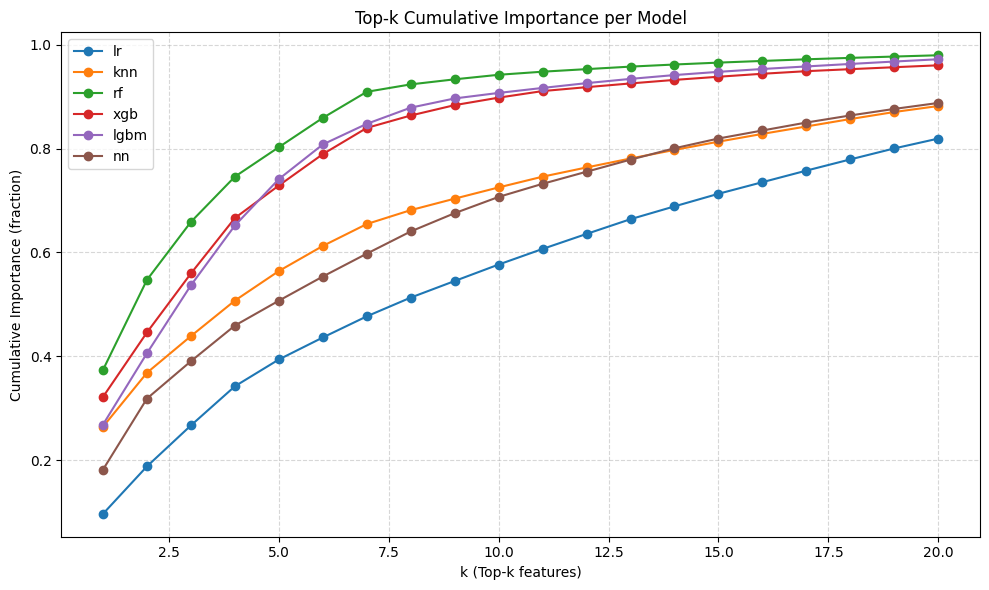

In [4]:
import numpy as np

def top_k_cumulative_importance(values, k=10):
    values = np.array(values)
    if len(values) == 0 or np.sum(values) == 0:
        return 0.0
    top_k_sum = np.sum(np.sort(values)[-k:])
    return top_k_sum / np.sum(values)

top_k_cum = {}
k = 5
for model, feature_scores in shap_scores.items():
    values = list(feature_scores.values())
    top_k_cum[model] = top_k_cumulative_importance(values, k=k)

print(f"Top-{k} cumulative importance per model:")
for model, cum in top_k_cum.items():
    print(f"{model}: {cum:.4f}")

    # INSERT_YOUR_CODE
import matplotlib.pyplot as plt

k_values = list(range(1, 21))
model_names = list(shap_scores.keys())
top_k_cum_matrix = {model: [] for model in model_names}

for k in k_values:
    for model, feature_scores in shap_scores.items():
        values = list(feature_scores.values())
        cum = top_k_cumulative_importance(values, k=k)
        top_k_cum_matrix[model].append(cum)

plt.figure(figsize=(10, 6))
for model in model_names:
    plt.plot(k_values, top_k_cum_matrix[model], marker='o', label=model)

plt.xlabel("k (Top-k features)")
plt.ylabel("Cumulative Importance (fraction)")
plt.title("Top-k Cumulative Importance per Model")
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.show()

